# 03_model_training — Обучение моделей

**Цель ноутбука:**  
Обучить бинарные классификаторы на основе CatBoost для предсказания инцидентов ИБ.
Модели обучаются раздельно для каждого сегмента (infrastructure_cluster × threat_cluster)
и для двух горизонтов прогнозирования: 24 часа и 7 дней.

**Архитектура:**

```
dataset_features.parquet
        ↓
[Для каждого сегмента (infra × threat)]
        ↓
  Временной split (70% train / 15% val / 15% test)
        ↓
  CatBoostClassifier (scale_pos_weight для дисбаланса)
        ↓
  Оценка: ROC-AUC, PR-AUC, F1
        ↓
  Сохранение моделей + метаданных
```

**Входные файлы:**
- `data/interim/dataset_features.parquet`
- `data/interim/feature_meta.json`

**Выходные файлы:**
- `mvp/models/24h/<infra>_<threat>.cbm` — модели для 24-часового горизонта
- `mvp/models/7d/<infra>_<threat>.cbm` — модели для 7-дневного горизонта
- `mvp/models/results_24h.csv` — метрики качества
- `mvp/models/results_7d.csv` — метрики качества


## 1. Установка зависимостей

In [1]:
!pip install catboost -q
!pip install optuna -q

import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
from pathlib import Path

import catboost as cb
import optuna

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Загрузка данных и метаданных признаков

In [2]:
# Ноутбуки в notebooks/, корень проекта — на уровень выше
base_path = Path('..')
data_dir = base_path / 'data' / 'processed'

# Загружаем датасет с признаками
dataset_model = pd.read_parquet(data_dir / 'dataset_features.parquet')

# Загружаем список признаков (создан в 02_feature_engineering.ipynb)
with open(data_dir / 'feature_meta.json', 'r') as f:
    meta = json.load(f)

feature_cols = meta['feature_cols']
cat_features = meta['cat_features']
target_cols = meta['target_cols']

print(f"Датасет: {dataset_model.shape}")
print(f"Признаков: {len(feature_cols)}")
print(f"Категориальных: {len(cat_features)}")
print(f"Целевые переменные: {target_cols}")
print(f"\nРаспределение целевых переменных:")
for t in target_cols:
    print(f"  {t}: {dataset_model[t].mean():.4f} positives")

Датасет: (26112, 51)
Признаков: 21
Категориальных: 3
Целевые переменные: ['target_next_24h', 'target_next_7d', 'days_until_next_attack', 'attack_window_class']

Распределение целевых переменных:
  target_next_24h: 0.0708 positives
  target_next_7d: 0.4003 positives
  days_until_next_attack: 13.1944 positives
  attack_window_class: 2.5075 positives


## 3. Вспомогательные функции

### `add_rolling` — скользящие признаки

Функция добавляет rolling-признаки к произвольному датафрейму.
Используется отдельно для train/val/test, чтобы избежать leakage между частями.


In [3]:
# ================================================================
# ЕДИНАЯ add_rolling для всех трёх тренировочных ноутбуков
# Пересчитывает все rolling-зависимые признаки из feature_cols
# без data leakage (shift(1) перед окном).
#
# Требует наличия в df:
#   incidents_count_day, success_count_day, had_incident_today
#   lag_inc_1d (вычисляется внутри функции)
# ================================================================

def add_rolling(df_part: pd.DataFrame) -> pd.DataFrame:
    """
    Пересчитывает все rolling-зависимые признаки для заданного сплита.

    Применяется отдельно к train/val/test, чтобы не было data leakage
    между сплитами. Внутри каждого сплита сортировка по дате сохраняется.

    Признаки (соответствуют feature_meta.json из 02_feature_engineering_v2):
        Скользящие суммы:
            inc_3d_sum, inc_7d_sum, inc_30d_sum
            succ_7d_sum, succ_30d_sum
        Бинарные флаги:
            had_incident_prev_1d, had_incident_prev_3d, had_incident_prev_7d
        Временные (с последнего события):
            days_since_last_incident
        Интенсивность и тренды:
            avg_inter_attack_interval, attack_rate_trend
            streak_active_days, streak_quiet_days
            success_ratio_7d
    """
    import numpy as np
    import pandas as pd

    df_part = df_part.copy()
    grp = df_part.groupby(['infrastructure_cluster', 'threat_cluster'])

    # --- lag_inc_1d (нужен для had_incident_prev_1d) ---
    df_part['lag_inc_1d'] = grp['incidents_count_day'].shift(1).fillna(0)

    # --- Скользящие суммы инцидентов ---
    for window, col in [(3, 'inc_3d_sum'), (7, 'inc_7d_sum'), (30, 'inc_30d_sum')]:
        df_part[col] = (
            grp['incidents_count_day']
            .shift(1)
            .rolling(window, min_periods=1)
            .sum()
            .reset_index(drop=True)
            .fillna(0)
        )

    # --- Скользящие суммы успешных атак ---
    for window, col in [(7, 'succ_7d_sum'), (30, 'succ_30d_sum')]:
        df_part[col] = (
            grp['success_count_day']
            .shift(1)
            .rolling(window, min_periods=1)
            .sum()
            .reset_index(drop=True)
            .fillna(0)
        )

    # --- Бинарные флаги активности ---
    df_part['had_incident_prev_1d'] = (df_part['lag_inc_1d'] > 0).astype(int)
    df_part['had_incident_prev_3d'] = (df_part['inc_3d_sum'] > 0).astype(int)
    df_part['had_incident_prev_7d'] = (df_part['inc_7d_sum'] > 0).astype(int)

    # --- days_since_last_incident ---
    def _days_since_last_event(series: pd.Series) -> pd.Series:
        result = []
        last_day = None
        for i, val in enumerate(series):
            if last_day is None:
                result.append(np.nan)
            else:
                result.append(i - last_day)
            if val > 0:
                last_day = i
        return pd.Series(result, index=series.index)

    df_part['days_since_last_incident'] = (
        grp['had_incident_today']
        .apply(_days_since_last_event)
        .reset_index(level=[0, 1], drop=True)
        .fillna(999)
    )

    # --- avg_inter_attack_interval ---
    df_part['avg_inter_attack_interval'] = (
        grp['days_since_last_incident']
        .shift(1)
        .rolling(30, min_periods=3)
        .mean()
        .reset_index(drop=True)
        .fillna(999)
    )

    # --- attack_rate_trend ---
    df_part['attack_rate_trend'] = (
        df_part['inc_7d_sum'].fillna(0) - df_part['inc_30d_sum'].fillna(0) / (30 / 7)
    )

    # --- streak_active_days / streak_quiet_days ---
    def _calc_streak(series, active=True):
        result = []
        streak = 0
        for val in series:
            condition = (val > 0) if active else (val == 0)
            if condition:
                streak += 1
            else:
                streak = 0
            result.append(streak)
        return pd.Series(result, index=series.index)

    df_part['streak_active_days'] = (
        grp['had_incident_today']
        .shift(1)
        .fillna(0)
        .transform(lambda s: _calc_streak(s, active=True))
    )
    df_part['streak_quiet_days'] = (
        grp['had_incident_today']
        .shift(1)
        .fillna(0)
        .transform(lambda s: _calc_streak(s, active=False))
    )

    # --- success_ratio_7d ---
    df_part['success_ratio_7d'] = np.where(
        df_part['inc_7d_sum'].fillna(0) > 0,
        df_part['succ_7d_sum'].fillna(0) / df_part['inc_7d_sum'].fillna(1),
        0.0
    )

    return df_part


## 4. Функция обучения по сегментам

### Логика сегментированного обучения

Для каждой пары (infrastructure_cluster, threat_cluster) обучается своя модель.

**Почему?**  
Паттерны атак принципиально разные для:
- IT-компаний vs промышленных предприятий
- Malware-атак vs DDoS-атак

Единая модель «усредняла» бы эти паттерны и теряла бы точность.

### Временной split

```
|<------ 70% train ------>|<-- 15% val -->|<-- 15% test -->|
                         ↑               ↑
                      train_end        val_end
```

Строго хронологический (no shuffle) — иначе утечка данных из будущего в прошлое.

### Работа с дисбалансом классов

Инциденты — редкое событие (10-30% дней). Используем `scale_pos_weight`:

```
scale_pos_weight = n_negative / n_positive
```

Это штрафует модель сильнее за пропуск положительного класса.


In [4]:
def compute_class_weights(y_train, n_classes: int):
    counts = np.bincount(y_train.astype(int), minlength=n_classes)
    total = counts.sum()
    weights = []

    for c in range(n_classes):
        if counts[c] > 0:
            weights.append(total / (n_classes * counts[c]))
        else:
            weights.append(1.0)

    return weights

In [5]:
from sklearn.model_selection import TimeSeriesSplit

In [6]:
def train_binary_models_by_segments(
    data: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    cat_features: list,
    min_rows: int = 120,
    min_positive: int = 10,
    verbose: bool = True
) -> tuple:
    """
    Обучает отдельную CatBoost-модель для каждого сегмента (infra × threat).

    Параметры:
    ----------
    data : pd.DataFrame
        Датасет с признаками и целевой переменной.
    feature_cols : list
        Список имён признаков.
    target_col : str
        Имя целевой переменной ('target_next_24h' или 'target_next_7d').
    cat_features : list
        Список категориальных признаков для CatBoost.
    min_rows : int
        Минимальное количество строк для обучения сегмента (по умолчанию 120).
    min_positive : int
        Минимальное количество положительных примеров (по умолчанию 10).
    verbose : bool
        Выводить ли лог обучения.

    Возвращает:
    ----------
    models : dict
        Словарь {(infra, threat): CatBoostClassifier}
    results_df : pd.DataFrame
        Таблица метрик по всем сегментам.
    """
    models = {}
    results = []

    # Уникальные значения кластеров
    infra_values = sorted(data['infrastructure_cluster'].astype(str).unique())
    threat_values = sorted(data['threat_cluster'].dropna().astype(int).unique())

    for infra_value in infra_values:
        for threat_value in threat_values:

            # Извлекаем данные сегмента
            part = data[
                (data['infrastructure_cluster'].astype(str) == str(infra_value)) &
                (data['threat_cluster'].astype(int) == int(threat_value))
            ].copy()

            n_rows = len(part)
            n_pos = part[target_col].sum() if n_rows > 0 else 0
            pos_rate = n_pos / n_rows if n_rows > 0 else np.nan

            seg_label = f"infra={infra_value}, threat={threat_value}"

            if verbose:
                print(f"\n{'='*80}")
                print(f"Сегмент: {seg_label} | target={target_col}")
                print(f"  Строк: {n_rows} | Positives: {n_pos} ({pos_rate:.4f})")

            # Проверка минимальных требований к сегменту
            if n_rows < min_rows:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: слишком мало строк (нужно >= {min_rows})")
                continue

            if n_pos < min_positive:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: мало положительных примеров (нужно >= {min_positive})")
                continue

            if n_pos == n_rows:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: все примеры положительные (один класс)")
                continue

            # Сортируем по дате — критически важно для временного split'а
            part = part.sort_values('date').reset_index(drop=True)

            unique_dates = np.array(sorted(part['date'].unique()))
            n_dates = len(unique_dates)

            if n_dates < 30:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: мало уникальных дат ({n_dates} < 30)")
                continue

            # --- Временной split: 70% / 15% / 15% ---
            train_end = int(n_dates * 0.70)
            val_end   = int(n_dates * 0.85)

            train_dates = unique_dates[:train_end]
            val_dates   = unique_dates[train_end:val_end]
            test_dates  = unique_dates[val_end:]

            train_df = part[part['date'].isin(train_dates)].copy()
            val_df   = part[part['date'].isin(val_dates)].copy()
            test_df  = part[part['date'].isin(test_dates)].copy()

            # Добавляем rolling-признаки к каждому split'у независимо
            # (чтобы rolling не «видело» данные из val при обучении)
            train_df = add_rolling(train_df)
            val_df   = add_rolling(val_df)
            test_df  = add_rolling(test_df)

            if verbose:
                print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

            # Формируем матрицы признаков и целевые векторы
            X_train = train_df[feature_cols].copy()
            y_train = train_df[target_col].copy()
            X_val   = val_df[feature_cols].copy()
            y_val   = val_df[target_col].copy()
            X_test  = test_df[feature_cols].copy()
            y_test  = test_df[target_col].copy()

            # Категориальные признаки → строки (требование CatBoost)
            local_cat = [c for c in cat_features if c in feature_cols]
            for col in local_cat:
                X_train[col] = X_train[col].astype(str)
                X_val[col]   = X_val[col].astype(str)
                X_test[col]  = X_test[col].astype(str)

            # Обёртки CatBoost Pool
            train_pool = cb.Pool(X_train, y_train, cat_features=local_cat)
            val_pool   = cb.Pool(X_val,   y_val,   cat_features=local_cat)

            # Вес для компенсации дисбаланса классов
            n_neg = (y_train == 0).sum()
            n_pos_train = (y_train == 1).sum()
            scale_pos = n_neg / max(n_pos_train, 1)

            # --- Обучение CatBoostClassifier ---
            model = cb.CatBoostClassifier(
                iterations=500,           # число деревьев
                learning_rate=0.05,       # шаг градиентного спуска
                depth=6,                  # глубина дерева
                l2_leaf_reg=3,            # L2-регуляризация листьев
                scale_pos_weight=scale_pos,  # компенсация дисбаланса
                eval_metric='AUC',        # метрика для early stopping
                early_stopping_rounds=50, # останавливаемся, если нет улучшения
                random_seed=42,
                verbose=0                 # отключаем вывод CatBoost
            )

            model.fit(
                train_pool,
                eval_set=val_pool,
                use_best_model=True       # берём модель на лучшей итерации по val
            )

            # --- Оценка качества ---
            # Вероятности для ROC-AUC и PR-AUC
            val_proba  = model.predict_proba(X_val)[:, 1]
            test_proba = model.predict_proba(X_test)[:, 1]

            # Бинарные предсказания (threshold = 0.5)
            val_pred  = (val_proba  > 0.5).astype(int)
            test_pred = (test_proba > 0.5).astype(int)

            val_roc  = roc_auc_score(y_val, val_proba)   if y_val.nunique() > 1 else np.nan
            val_pr   = average_precision_score(y_val, val_proba) if y_val.nunique() > 1 else np.nan
            val_f1   = f1_score(y_val, val_pred, zero_division=0)

            test_roc = roc_auc_score(y_test, test_proba)  if y_test.nunique() > 1 else np.nan
            test_pr  = average_precision_score(y_test, test_proba) if y_test.nunique() > 1 else np.nan
            test_f1  = f1_score(y_test, test_pred, zero_division=0)

            if verbose:
                print(f"  Val:  ROC-AUC={val_roc:.4f}  PR-AUC={val_pr:.4f}  F1={val_f1:.4f}")
                print(f"  Test: ROC-AUC={test_roc:.4f} PR-AUC={test_pr:.4f} F1={test_f1:.4f}")

            # Сохраняем модель и результаты
            models[(str(infra_value), int(threat_value))] = model
            results.append({
                'infrastructure_cluster': infra_value,
                'threat_cluster': threat_value,
                'target': target_col,
                'n_rows': n_rows,
                'n_positive': n_pos,
                'pos_rate': round(pos_rate, 4),
                'train_size': len(train_df),
                'val_size': len(val_df),
                'test_size': len(test_df),
                'val_roc_auc': round(val_roc, 4) if not np.isnan(val_roc) else None,
                'val_pr_auc': round(val_pr, 4) if not np.isnan(val_pr) else None,
                'val_f1': round(val_f1, 4),
                'test_roc_auc': round(test_roc, 4) if not np.isnan(test_roc) else None,
                'test_pr_auc': round(test_pr, 4) if not np.isnan(test_pr) else None,
                'test_f1': round(test_f1, 4),
                'best_iteration': model.get_best_iteration()
            })

    results_df = pd.DataFrame(results)
    return models, results_df


print("Функция train_binary_models_by_segments определена")

Функция train_binary_models_by_segments определена


## 5. Обучение моделей: горизонт 24 часа

Предсказываем: **будет ли инцидент завтра?**

Это наиболее оперативный горизонт — актуален для daily-мониторинга и оперативных оповещений.


In [7]:
print("Начинаем обучение моделей для горизонта 24 часа...")
print(f"Всего сегментов для обхода: {dataset_model['infrastructure_cluster'].nunique()} × {dataset_model['threat_cluster'].nunique()}")

models_24h, results_24h = train_binary_models_by_segments(
    data=dataset_model,
    feature_cols=feature_cols,
    target_col='target_next_24h',
    cat_features=cat_features,
    min_rows=120,
    min_positive=10,
   # n_trials=20,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Обучено моделей: {len(models_24h)}")
print(f"\nТаблица результатов (по убыванию PR-AUC):")
display(results_24h.sort_values('test_pr_auc', ascending=False).round(4))

Начинаем обучение моделей для горизонта 24 часа...
Всего сегментов для обхода: 4 × 6

Сегмент: infra=1, threat=1 | target=target_next_24h
  Строк: 1088 | Positives: 64 (0.0588)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.7685  PR-AUC=0.3105  F1=0.3902
  Test: ROC-AUC=0.4737 PR-AUC=0.0641 F1=0.1132

Сегмент: infra=1, threat=2 | target=target_next_24h
  Строк: 1088 | Positives: 69 (0.0634)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.4581  PR-AUC=0.0892  F1=0.0667
  Test: ROC-AUC=0.4997 PR-AUC=0.0634 F1=0.0000

Сегмент: infra=1, threat=3 | target=target_next_24h
  Строк: 1088 | Positives: 66 (0.0607)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6284  PR-AUC=0.2203  F1=0.1818
  Test: ROC-AUC=0.4106 PR-AUC=0.0676 F1=0.0000

Сегмент: infra=1, threat=4 | target=target_next_24h
  Строк: 1088 | Positives: 90 (0.0827)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6211  PR-AUC=0.0954  F1=0.0000
  Test: ROC-AUC=0.4094 PR-AUC=0.1311 F1=0.1053

Сегмент: infra=1, 

,infrastructure_cluster,threat_cluster,target,n_rows,n_positive,pos_rate,train_size,val_size,test_size,val_roc_auc,val_pr_auc,val_f1,test_roc_auc,test_pr_auc,test_f1,best_iteration
8,2,3,target_next_24h,1088,97,0.0892,761,163,164,0.5586,0.1309,0.0000,0.5094,0.1578,0.1333,41
15,3,4,target_next_24h,1088,94,0.0864,761,163,164,0.5558,0.1145,0.1471,0.6706,0.1439,0.0896,4
3,1,4,target_next_24h,1088,90,0.0827,761,163,164,0.6211,0.0954,0.0000,0.4094,0.1311,0.1053,9
16,3,5,target_next_24h,1088,76,0.0699,761,163,164,0.5907,0.0689,0.1053,0.5472,0.1109,0.0952,13
4,1,5,target_next_24h,1088,82,0.0754,761,163,164,0.5233,0.0947,0.1096,0.6541,0.1052,0.1951,0
20,4,3,target_next_24h,1088,69,0.0634,761,163,164,0.4044,0.0297,0.0404,0.5101,0.0963,0.1688,4
14,3,3,target_next_24h,1088,82,0.0754,761,163,164,0.5615,0.1040,0.0513,0.4570,0.0931,0.1176,33
7,2,2,target_next_24h,1088,79,0.0726,761,163,164,0.5853,0.0925,0.1389,0.4877,0.0921,0.1250,2
12,3,1,target_next_24h,1088,65,0.0597,761,163,164,0.6927,0.0409,0.0000,0.5238,0.0851,0.0000,2
6,2,1,target_next_24h,1088,79,0.0726,761,163,164,0.5772,0.1161,0.1707,0.5707,0.0849,0.1351,1


## 6. Обучение моделей: горизонт 7 дней

Предсказываем: **будет ли инцидент в течение следующей недели?**

Горизонт 7 дней актуален для еженедельного планирования защитных мероприятий.
Обычно положительных примеров больше → задача проще, но модель должна быть устойчивее.


In [8]:
print("Начинаем обучение моделей для горизонта 7 дней...")

models_7d, results_7d = train_binary_models_by_segments(
    data=dataset_model,
    feature_cols=feature_cols,
    target_col='target_next_7d',
    cat_features=cat_features,
    min_rows=120,
    min_positive=10,
    #n_trials=20,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Обучено моделей: {len(models_7d)}")
print(f"\nТаблица результатов (по убыванию PR-AUC):")
display(results_7d.sort_values('test_pr_auc', ascending=False).round(4))

Начинаем обучение моделей для горизонта 7 дней...

Сегмент: infra=1, threat=1 | target=target_next_7d
  Строк: 1088 | Positives: 364 (0.3346)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6878  PR-AUC=0.6264  F1=0.1795
  Test: ROC-AUC=0.7421 PR-AUC=0.6707 F1=0.2222

Сегмент: infra=1, threat=2 | target=target_next_7d
  Строк: 1088 | Positives: 409 (0.3759)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6726  PR-AUC=0.7090  F1=0.5921
  Test: ROC-AUC=0.6801 PR-AUC=0.4959 F1=0.1846

Сегмент: infra=1, threat=3 | target=target_next_7d
  Строк: 1088 | Positives: 415 (0.3814)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6148  PR-AUC=0.5796  F1=0.5872
  Test: ROC-AUC=0.5535 PR-AUC=0.4628 F1=0.4035

Сегмент: infra=1, threat=4 | target=target_next_7d
  Строк: 1088 | Positives: 500 (0.4596)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.5870  PR-AUC=0.5614  F1=0.0690
  Test: ROC-AUC=0.5955 PR-AUC=0.4951 F1=0.0000

Сегмент: infra=1, threat=5 | target=target_next_7d
  

,infrastructure_cluster,threat_cluster,target,n_rows,n_positive,pos_rate,train_size,val_size,test_size,val_roc_auc,val_pr_auc,val_f1,test_roc_auc,test_pr_auc,test_f1,best_iteration
0,1,1,target_next_7d,1088,364,0.3346,761,163,164,0.6878,0.6264,0.1795,0.7421,0.6707,0.2222,29
19,4,2,target_next_7d,1088,447,0.4108,761,163,164,0.5738,0.5804,0.4054,0.6651,0.5541,0.6154,1
13,3,2,target_next_7d,1088,503,0.4623,761,163,164,0.4262,0.3689,0.1553,0.5738,0.5360,0.3802,134
20,4,3,target_next_7d,1088,386,0.3548,761,163,164,0.4897,0.1690,0.1200,0.5023,0.5045,0.3089,44
21,4,4,target_next_7d,1088,440,0.4044,761,163,164,0.6920,0.6872,0.6296,0.7236,0.4999,0.6165,8
8,2,3,target_next_7d,1088,502,0.4614,761,163,164,0.6461,0.6463,0.1538,0.4995,0.4968,0.4539,184
1,1,2,target_next_7d,1088,409,0.3759,761,163,164,0.6726,0.7090,0.5921,0.6801,0.4959,0.1846,3
3,1,4,target_next_7d,1088,500,0.4596,761,163,164,0.5870,0.5614,0.0690,0.5955,0.4951,0.0000,139
18,4,1,target_next_7d,1088,404,0.3713,761,163,164,0.8243,0.3303,0.3939,0.5580,0.4910,0.0230,55
11,2,6,target_next_7d,1088,358,0.3290,761,163,164,0.5358,0.4116,0.3178,0.5466,0.4861,0.3000,18


## 7. Анализ результатов обучения

Визуализируем качество моделей и понимаем, для каких сегментов модели работают лучше.


In [9]:
# Сравнительная таблица по обоим горизонтам
results_24h['horizon'] = '24h'
results_7d['horizon'] = '7d'

all_results = pd.concat([results_24h, results_7d], ignore_index=True)

# Сводная статистика
print("=== Статистика качества моделей ===\n")
for horizon in ['24h', '7d']:
    df_h = all_results[all_results['horizon'] == horizon]
    print(f"Горизонт {horizon}:")
    print(f"  Моделей обучено: {len(df_h)}")
    print(f"  ROC-AUC: mean={df_h['test_roc_auc'].mean():.4f}, "
          f"min={df_h['test_roc_auc'].min():.4f}, "
          f"max={df_h['test_roc_auc'].max():.4f}")
    print(f"  PR-AUC:  mean={df_h['test_pr_auc'].mean():.4f}, "
          f"min={df_h['test_pr_auc'].min():.4f}, "
          f"max={df_h['test_pr_auc'].max():.4f}")
    print()

=== Статистика качества моделей ===

Горизонт 24h:
  Моделей обучено: 24
  ROC-AUC: mean=0.4871, min=0.3398, max=0.6706
  PR-AUC:  mean=0.0855, min=0.0449, max=0.1578

Горизонт 7d:
  Моделей обучено: 24
  ROC-AUC: mean=0.5260, min=0.2242, max=0.7421
  PR-AUC:  mean=0.4365, min=0.2183, max=0.6707



In [10]:
# ============================================================
# SHAP + ABLATION для 03_model_training.ipynb
# Вставить ПОСЛЕ обучения models24h/results24h и models7d/results7d
# ============================================================

!pip install -q shap

import os
import json
import shap
import numpy as np
import pandas as pd
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

ARTIFACTS_DIR = Path("..") / "ml" / "models" / "v1" / "interp"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Artifacts dir: /home/max/projects/rsm_hackathon_2026/ml/models/v1/interp


In [11]:
# ============================================================
# Вспомогательные функции
# ============================================================

def _prepare_X_for_catboost(X: pd.DataFrame, cat_cols: list) -> pd.DataFrame:
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype(str)
    return X


def _split_segment_part(part: pd.DataFrame):
    part = part.sort_values("date").reset_index(drop=True)
    unique_dates = np.array(sorted(part["date"].unique()))
    ndates = len(unique_dates)

    if ndates < 30:
        raise ValueError(f"Слишком мало дат в сегменте: {ndates}")

    train_end = int(ndates * 0.70)
    val_end = int(ndates * 0.85)

    train_dates = unique_dates[:train_end]
    val_dates = unique_dates[train_end:val_end]
    test_dates = unique_dates[val_end:]

    train_df = add_rolling(part[part["date"].isin(train_dates)].copy())
    val_df = add_rolling(part[part["date"].isin(val_dates)].copy())
    test_df = add_rolling(part[part["date"].isin(test_dates)].copy())

    return train_df, val_df, test_df


def get_segment_split(dataset: pd.DataFrame, infra_value, threat_value):
    part = dataset[
        (dataset["infrastructure_cluster"].astype(str) == str(infra_value)) &
        (dataset["threat_cluster"].astype(int) == int(threat_value))
    ].copy()

    if len(part) == 0:
        raise ValueError(f"Пустой сегмент infra={infra_value}, threat={threat_value}")

    return _split_segment_part(part)


def fit_catboost_segment(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list,
    cat_cols: list,
    target_col: str,
    n_trials=20,
    threshold: float = 0.5
):
    X_train = _prepare_X_for_catboost(train_df[feature_cols].copy(), cat_cols)
    y_train = train_df[target_col].copy()

    X_val = _prepare_X_for_catboost(val_df[feature_cols].copy(), cat_cols)
    y_val = val_df[target_col].copy()

    X_test = _prepare_X_for_catboost(test_df[feature_cols].copy(), cat_cols)
    y_test = test_df[target_col].copy()

    local_cat = [c for c in cat_cols if c in feature_cols]

    train_pool = cb.Pool(X_train, y_train, cat_features=local_cat)
    val_pool = cb.Pool(X_val, y_val, cat_features=local_cat)

    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    scale_pos = n_neg / max(n_pos, 1)

    model = cb.CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        scale_pos_weight=scale_pos,
        eval_metric="AUC",
        early_stopping_rounds=50,
        random_seed=42,
        verbose=0
    )

    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_proba = model.predict_proba(X_val)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    val_pred = (val_proba >= threshold).astype(int)
    test_pred = (test_proba >= threshold).astype(int)

    metrics = {
        "val_roc_auc": roc_auc_score(y_val, val_proba) if y_val.nunique() > 1 else np.nan,
        "val_pr_auc": average_precision_score(y_val, val_proba) if y_val.nunique() > 1 else np.nan,
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, test_proba) if y_test.nunique() > 1 else np.nan,
        "test_pr_auc": average_precision_score(y_test, test_proba) if y_test.nunique() > 1 else np.nan,
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "best_iteration": model.get_best_iteration()
    }

    return model, metrics, X_train, y_train, X_val, y_val, X_test, y_test


def infer_feature_groups(feature_cols: list):
    groups = {
        "calendar": [],
        "rolling_incidents": [],
        "rolling_success": [],
        "history_flags": [],
        "lags": [],
        "segment_meta": [],
        "size_profile": [],
        "other": []
    }

    for col in feature_cols:
        c = col.lower()

        if any(x in c for x in ["day_of_week", "day_of_month", "month", "week", "weekend", "holiday"]):
            groups["calendar"].append(col)
        elif "succ" in c:
            groups["rolling_success"].append(col)
        elif any(x in c for x in ["inc3d", "inc7d", "inc30d", "incident_count", "type_inc"]):
            groups["rolling_incidents"].append(col)
        elif any(x in c for x in ["had_incident", "has_incident"]):
            groups["history_flags"].append(col)
        elif "lag" in c:
            groups["lags"].append(col)
        elif any(x in c for x in ["infrastructure_cluster", "threat_cluster"]):
            groups["segment_meta"].append(col)
        elif any(x in c for x in ["hosts", "sizeclass", "hostscount", "hostslog", "companysize"]):
            groups["size_profile"].append(col)
        else:
            groups["other"].append(col)

    groups = {k: v for k, v in groups.items() if len(v) > 0}
    return groups


FEATURE_GROUPS = infer_feature_groups(feature_cols)

print("Группы признаков:")
for k, v in FEATURE_GROUPS.items():
    print(f"- {k}: {len(v)}")

Группы признаков:
- calendar: 3
- rolling_incidents: 2
- rolling_success: 4
- history_flags: 3
- lags: 1
- other: 8


In [12]:
# ============================================================
# SHAP для одного сегмента
# ============================================================

def run_shap_for_segment(
    model,
    X_sample: pd.DataFrame,
    y_sample: pd.Series,
    cat_cols: list,
    segment_label: str,
    horizon_label: str,
    top_n: int = 15,
    max_rows: int = 300,
    save_dir: Path = ARTIFACTS_DIR
):
    if len(X_sample) > max_rows:
        sample_idx = X_sample.sample(max_rows, random_state=42).index
        X_sample = X_sample.loc[sample_idx].copy()
        y_sample = y_sample.loc[sample_idx].copy()

    X_sample = _prepare_X_for_catboost(X_sample, cat_cols)
    local_cat = [c for c in cat_cols if c in X_sample.columns]
    pool = cb.Pool(X_sample, y_sample, cat_features=local_cat)

    shap_values = model.get_feature_importance(pool, type="ShapValues")
    shap_contrib = pd.DataFrame(
        shap_values[:, :-1],
        columns=X_sample.columns,
        index=X_sample.index
    )

    shap_global = (
        shap_contrib.abs()
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    shap_global.columns = ["feature", "mean_abs_shap"]
    shap_global["segment"] = segment_label
    shap_global["horizon"] = horizon_label

    csv_path = save_dir / f"shap_global_{horizon_label}_{segment_label}.csv"
    shap_global.to_csv(csv_path, index=False)

    top_df = shap_global.head(top_n).sort_values("mean_abs_shap", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["feature"], top_df["mean_abs_shap"], color="teal")
    plt.title(f"SHAP Global Importance | {horizon_label} | {segment_label}")
    plt.xlabel("mean(|SHAP|)")
    plt.tight_layout()
    plt.show()

    return shap_contrib, shap_global

In [13]:
# ============================================================
# Ablation для одного сегмента
# ============================================================

def run_ablation_for_segment(
    dataset: pd.DataFrame,
    infra_value,
    threat_value,
    target_col: str,
    feature_cols: list,
    cat_cols: list,
    feature_groups: dict,
    n_trials=0,
    threshold: float = 0.5
):
    train_df, val_df, test_df = get_segment_split(dataset, infra_value, threat_value)

    baseline_model, baseline_metrics, *_ = fit_catboost_segment(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
        cat_cols=cat_cols,
        target_col=target_col,
        n_trials=20,
        threshold=threshold
    )

    rows = [{
        "infrastructure_cluster": str(infra_value),
        "threat_cluster": int(threat_value),
        "target": target_col,
        "ablated_group": "none",
        "n_features": len(feature_cols),
        "val_roc_auc": baseline_metrics["val_roc_auc"],
        "val_pr_auc": baseline_metrics["val_pr_auc"],
        "val_f1": baseline_metrics["val_f1"],
        "test_roc_auc": baseline_metrics["test_roc_auc"],
        "test_pr_auc": baseline_metrics["test_pr_auc"],
        "test_f1": baseline_metrics["test_f1"],
        "delta_test_roc_auc": 0.0,
        "delta_test_pr_auc": 0.0,
        "delta_test_f1": 0.0,
    }]

    for group_name, group_cols in feature_groups.items():
        keep_cols = [c for c in feature_cols if c not in group_cols]
        keep_cat = [c for c in cat_cols if c in keep_cols]

        _, ab_metrics, *_ = fit_catboost_segment(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            feature_cols=keep_cols,
            cat_cols=keep_cat,
            target_col=target_col,
            threshold=threshold
        )

        rows.append({
            "infrastructure_cluster": str(infra_value),
            "threat_cluster": int(threat_value),
            "target": target_col,
            "ablated_group": group_name,
            "n_features": len(keep_cols),
            "val_roc_auc": ab_metrics["val_roc_auc"],
            "val_pr_auc": ab_metrics["val_pr_auc"],
            "val_f1": ab_metrics["val_f1"],
            "test_roc_auc": ab_metrics["test_roc_auc"],
            "test_pr_auc": ab_metrics["test_pr_auc"],
            "test_f1": ab_metrics["test_f1"],
            "delta_test_roc_auc": ab_metrics["test_roc_auc"] - baseline_metrics["test_roc_auc"] if pd.notna(ab_metrics["test_roc_auc"]) and pd.notna(baseline_metrics["test_roc_auc"]) else np.nan,
            "delta_test_pr_auc": ab_metrics["test_pr_auc"] - baseline_metrics["test_pr_auc"] if pd.notna(ab_metrics["test_pr_auc"]) and pd.notna(baseline_metrics["test_pr_auc"]) else np.nan,
            "delta_test_f1": ab_metrics["test_f1"] - baseline_metrics["test_f1"] if pd.notna(ab_metrics["test_f1"]) and pd.notna(baseline_metrics["test_f1"]) else np.nan,
        })

    return pd.DataFrame(rows), baseline_model

In [14]:
# ============================================================
# Выбрать лучшие сегменты и прогнать SHAP + Ablation
# ============================================================

def get_top_segments(results_df: pd.DataFrame, top_k: int = 3, sort_col: str = "test_pr_auc"):
    tmp = (
        results_df
        .dropna(subset=[sort_col])
        .sort_values(sort_col, ascending=False)
        .head(top_k)
        .copy()
    )
    return list(zip(tmp["infrastructure_cluster"].astype(str), tmp["threat_cluster"].astype(int)))


TOP_K = 3

top_segments_24h = get_top_segments(results_24h, top_k=TOP_K, sort_col="test_pr_auc")
top_segments_7d = get_top_segments(results_7d, top_k=TOP_K, sort_col="test_pr_auc")

print("Top 24h:", top_segments_24h)
print("Top 7d :", top_segments_7d)

Top 24h: [('2', 3), ('3', 4), ('1', 4)]
Top 7d : [('1', 1), ('4', 2), ('3', 2)]


24h | infra=2 | threat=3
{'val_roc_auc': 0.5585585585585585, 'val_pr_auc': 0.13087322159738823, 'val_f1': 0.0, 'test_roc_auc': 0.5094037615046019, 'test_pr_auc': 0.15777835312631366, 'test_f1': 0.13333333333333333, 'best_iteration': 41}


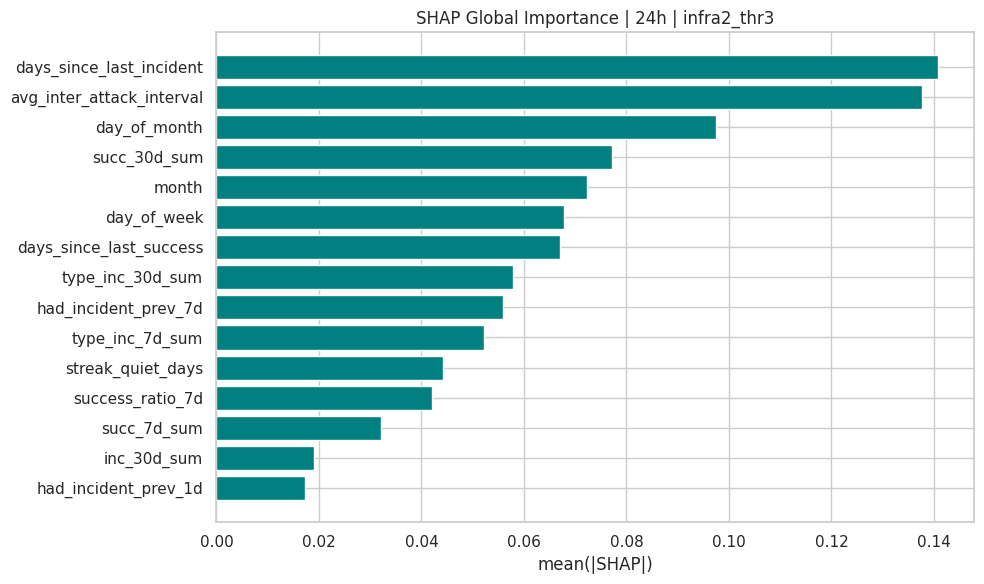

24h | infra=3 | threat=4
{'val_roc_auc': 0.5558485139022052, 'val_pr_auc': 0.11446882892410357, 'val_f1': 0.14705882352941177, 'test_roc_auc': 0.6706096451319381, 'test_pr_auc': 0.14387249392547874, 'test_f1': 0.08955223880597014, 'best_iteration': 4}


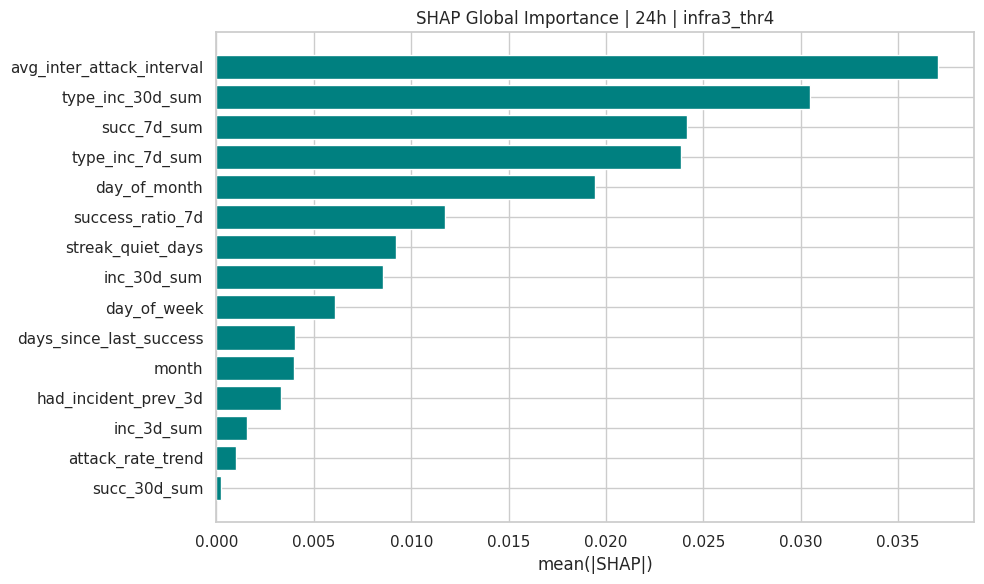

24h | infra=1 | threat=4
{'val_roc_auc': 0.6211368653421634, 'val_pr_auc': 0.0953870445852189, 'val_f1': 0.0, 'test_roc_auc': 0.40938799762329176, 'test_pr_auc': 0.13114022236141448, 'test_f1': 0.10526315789473684, 'best_iteration': 9}


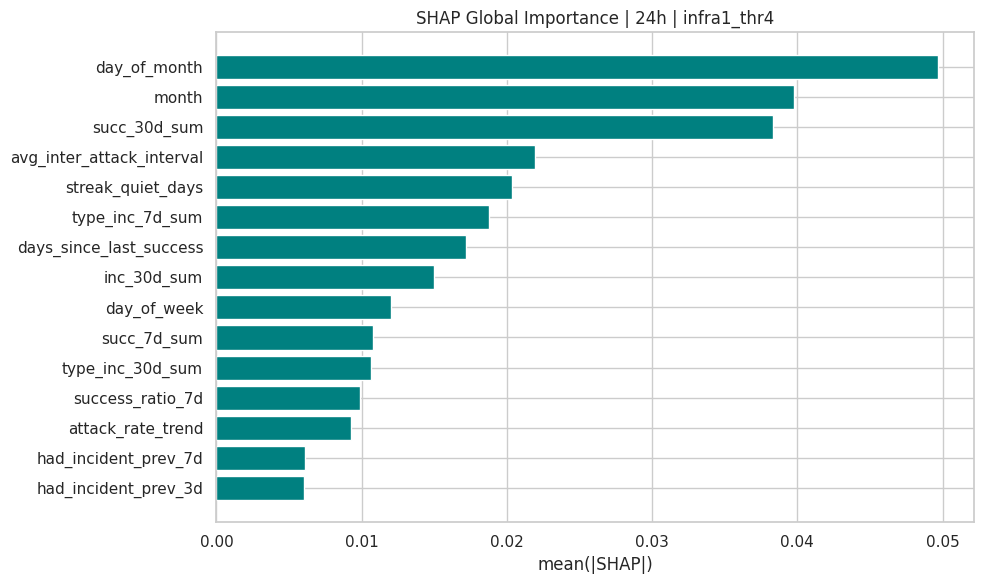

,infrastructure_cluster,threat_cluster,target,ablated_group,n_features,val_roc_auc,val_pr_auc,val_f1,test_roc_auc,test_pr_auc,test_f1,delta_test_roc_auc,delta_test_pr_auc,delta_test_f1
15,1,4,target_next_24h,calendar,18,0.592163,0.089502,0.131148,0.513072,0.092604,0.085106,0.103684,-0.038536,-0.020157
20,1,4,target_next_24h,other,13,0.641004,0.120114,0.163934,0.523767,0.100230,0.134615,0.114379,-0.030910,0.029352
19,1,4,target_next_24h,lags,20,0.520971,0.082690,0.000000,0.566845,0.118991,0.000000,0.157457,-0.012149,-0.105263
18,1,4,target_next_24h,history_flags,18,0.597130,0.120658,0.100000,0.569222,0.130519,0.095238,0.159834,-0.000621,-0.010025
17,1,4,target_next_24h,rolling_success,17,0.464680,0.070169,0.000000,0.673797,0.130890,0.000000,0.264409,-0.000250,-0.105263
14,1,4,target_next_24h,none,21,0.621137,0.095387,0.000000,0.409388,0.131140,0.105263,0.000000,0.000000,0.000000
16,1,4,target_next_24h,rolling_incidents,19,0.527042,0.092251,0.108108,0.525253,0.181786,0.105263,0.115865,0.050646,0.000000
3,2,3,target_next_24h,rolling_success,17,0.698874,0.185329,0.295082,0.542217,0.116800,0.186667,0.032813,-0.040979,0.053333
1,2,3,target_next_24h,calendar,18,0.552252,0.111593,0.080000,0.523609,0.120221,0.090909,0.014206,-0.037557,-0.042424
4,2,3,target_next_24h,history_flags,18,0.594595,0.205910,0.100000,0.578031,0.132448,0.171429,0.068627,-0.025330,0.038095


,feature,mean_abs_shap,segment,horizon
0,days_since_last_incident,0.140785,infra2_thr3,24h
1,avg_inter_attack_interval,0.137755,infra2_thr3,24h
2,day_of_month,0.097392,infra2_thr3,24h
3,succ_30d_sum,0.077257,infra2_thr3,24h
4,month,0.072228,infra2_thr3,24h
5,day_of_week,0.067842,infra2_thr3,24h
6,days_since_last_success,0.067057,infra2_thr3,24h
7,type_inc_30d_sum,0.057798,infra2_thr3,24h
8,had_incident_prev_7d,0.055993,infra2_thr3,24h
9,type_inc_7d_sum,0.052162,infra2_thr3,24h


In [15]:
# ============================================================
# Прогон 24h
# ============================================================

ablation_24h_all = []
shap_24h_all = []

for infra_value, threat_value in top_segments_24h:
    print("=" * 90)
    print(f"24h | infra={infra_value} | threat={threat_value}")

    segment_label = f"infra{infra_value}_thr{threat_value}"

    # split
    train_df, val_df, test_df = get_segment_split(dataset_model, infra_value, threat_value)

    # baseline retrain for clean SHAP
    model, metrics, X_train, y_train, X_val, y_val, X_test, y_test = fit_catboost_segment(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
        cat_cols=cat_features,
        target_col="target_next_24h",
        n_trials=0,
        threshold=0.5
    )

    print(metrics)

    # SHAP
    _, shap_global = run_shap_for_segment(
        model=model,
        X_sample=X_test,
        y_sample=y_test,
        cat_cols=cat_features,
        segment_label=segment_label,
        horizon_label="24h",
        top_n=15
    )
    shap_24h_all.append(shap_global)

    # Ablation
    ablation_df, _ = run_ablation_for_segment(
        dataset=dataset_model,
        infra_value=infra_value,
        threat_value=threat_value,
        target_col="target_next_24h",
        feature_cols=feature_cols,
        cat_cols=cat_features,
        feature_groups=FEATURE_GROUPS,
        threshold=0.5
    )
    ablation_24h_all.append(ablation_df)

ablation_24h_all = pd.concat(ablation_24h_all, ignore_index=True)
shap_24h_all = pd.concat(shap_24h_all, ignore_index=True)

ablation_24h_all.to_csv(ARTIFACTS_DIR / "ablation_24h_all.csv", index=False)
shap_24h_all.to_csv(ARTIFACTS_DIR / "shap_24h_all.csv", index=False)

display(ablation_24h_all.sort_values(["infrastructure_cluster", "threat_cluster", "delta_test_pr_auc"]))
display(shap_24h_all.head(30))

7d | infra=1 | threat=1
{'val_roc_auc': 0.6878444580526638, 'val_pr_auc': 0.626405517684393, 'val_f1': 0.1794871794871795, 'test_roc_auc': 0.7420634920634921, 'test_pr_auc': 0.6706837127425024, 'test_f1': 0.2222222222222222, 'best_iteration': 29}


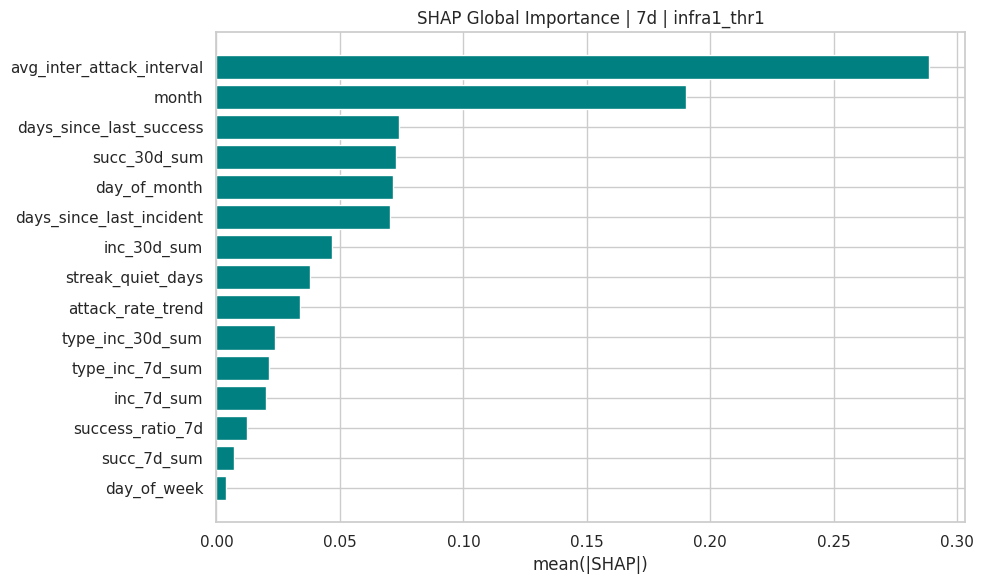

7d | infra=4 | threat=2
{'val_roc_auc': 0.5737729599518218, 'val_pr_auc': 0.5803696602159498, 'val_f1': 0.40540540540540543, 'test_roc_auc': 0.6651411136536995, 'test_pr_auc': 0.5540690987819326, 'test_f1': 0.6153846153846154, 'best_iteration': 1}


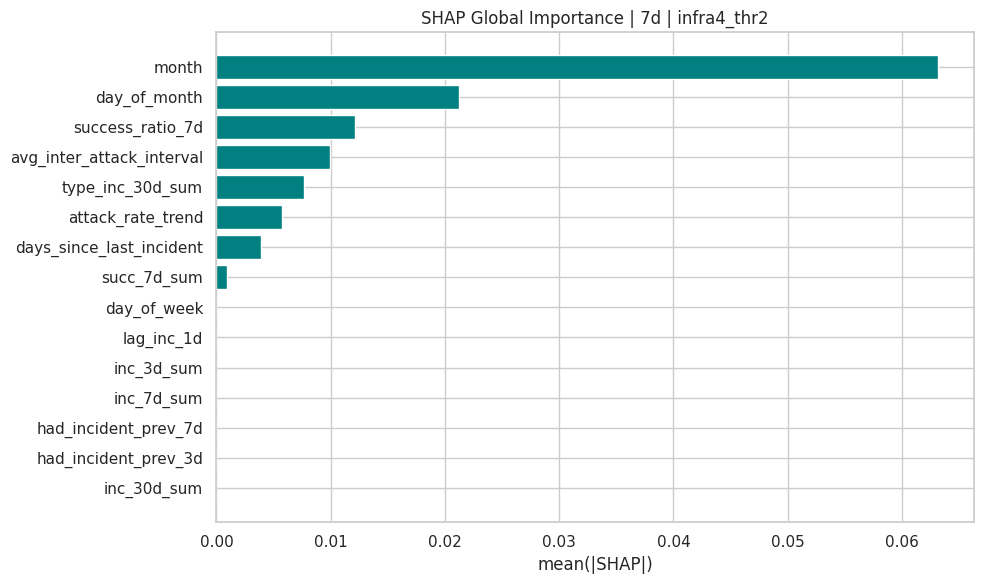

7d | infra=3 | threat=2
{'val_roc_auc': 0.4261609907120743, 'val_pr_auc': 0.3688999300212945, 'val_f1': 0.1553398058252427, 'test_roc_auc': 0.5737924865831843, 'test_pr_auc': 0.5359979538827214, 'test_f1': 0.38016528925619836, 'best_iteration': 134}


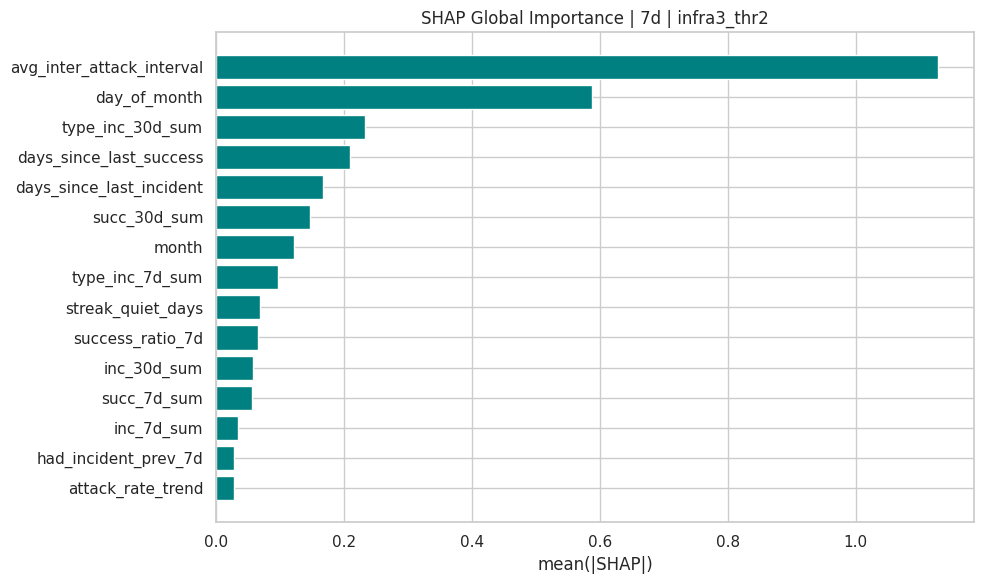

,infrastructure_cluster,threat_cluster,target,ablated_group,n_features,val_roc_auc,val_pr_auc,val_f1,test_roc_auc,test_pr_auc,test_f1,delta_test_roc_auc,delta_test_pr_auc,delta_test_f1
2,1,1,target_next_7d,rolling_incidents,19,0.779853,0.736667,0.081081,0.586640,0.476402,0.000000,-0.155423,-0.194282,-0.222222
4,1,1,target_next_7d,history_flags,18,0.774189,0.767512,0.528302,0.530589,0.489944,0.337662,-0.211475,-0.180739,0.115440
6,1,1,target_next_7d,other,13,0.795315,0.643811,0.718310,0.625496,0.511982,0.509091,-0.116567,-0.158702,0.286869
3,1,1,target_next_7d,rolling_success,17,0.723515,0.672667,0.462963,0.547206,0.523022,0.378378,-0.194858,-0.147661,0.156156
5,1,1,target_next_7d,lags,20,0.793631,0.715932,0.412371,0.603340,0.545458,0.133333,-0.138724,-0.125226,-0.088889
1,1,1,target_next_7d,calendar,18,0.624617,0.538566,0.363636,0.701472,0.629259,0.404762,-0.040592,-0.041425,0.182540
0,1,1,target_next_7d,none,21,0.687844,0.626406,0.179487,0.742063,0.670684,0.222222,0.000000,0.000000,0.000000
15,3,2,target_next_7d,calendar,18,0.500000,0.417178,0.588745,0.500000,0.475610,0.644628,-0.073792,-0.060388,0.264463
18,3,2,target_next_7d,history_flags,18,0.544892,0.520543,0.131579,0.431202,0.490408,0.293578,-0.142591,-0.045590,-0.086587
19,3,2,target_next_7d,lags,20,0.555573,0.456608,0.307692,0.547853,0.511036,0.252632,-0.025939,-0.024962,-0.127534


,feature,mean_abs_shap,segment,horizon
0,avg_inter_attack_interval,0.288554,infra1_thr1,7d
1,month,0.190285,infra1_thr1,7d
2,days_since_last_success,0.074053,infra1_thr1,7d
3,succ_30d_sum,0.072707,infra1_thr1,7d
4,day_of_month,0.071500,infra1_thr1,7d
5,days_since_last_incident,0.070248,infra1_thr1,7d
6,inc_30d_sum,0.046645,infra1_thr1,7d
7,streak_quiet_days,0.037804,infra1_thr1,7d
8,attack_rate_trend,0.033908,infra1_thr1,7d
9,type_inc_30d_sum,0.023873,infra1_thr1,7d


In [16]:
# ============================================================
# Прогон 7d
# ============================================================

ablation_7d_all = []
shap_7d_all = []

for infra_value, threat_value in top_segments_7d:
    print("=" * 90)
    print(f"7d | infra={infra_value} | threat={threat_value}")

    segment_label = f"infra{infra_value}_thr{threat_value}"

    # split
    train_df, val_df, test_df = get_segment_split(dataset_model, infra_value, threat_value)

    # baseline retrain for clean SHAP
    model, metrics, X_train, y_train, X_val, y_val, X_test, y_test = fit_catboost_segment(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
        cat_cols=cat_features,
        target_col="target_next_7d",
        n_trials=0,
        threshold=0.5
    )

    print(metrics)

    # SHAP
    _, shap_global = run_shap_for_segment(
        model=model,
        X_sample=X_test,
        y_sample=y_test,
        cat_cols=cat_features,
        segment_label=segment_label,
        horizon_label="7d",
        top_n=15
    )
    shap_7d_all.append(shap_global)

    # Ablation
    ablation_df, _ = run_ablation_for_segment(
        dataset=dataset_model,
        infra_value=infra_value,
        threat_value=threat_value,
        target_col="target_next_7d",
        feature_cols=feature_cols,
        cat_cols=cat_features,
        feature_groups=FEATURE_GROUPS,
        n_trials=20,
        threshold=0.5
    )
    ablation_7d_all.append(ablation_df)

ablation_7d_all = pd.concat(ablation_7d_all, ignore_index=True)
shap_7d_all = pd.concat(shap_7d_all, ignore_index=True)

ablation_7d_all.to_csv(ARTIFACTS_DIR / "ablation_7d_all.csv", index=False)
shap_7d_all.to_csv(ARTIFACTS_DIR / "shap_7d_all.csv", index=False)

display(ablation_7d_all.sort_values(["infrastructure_cluster", "threat_cluster", "delta_test_pr_auc"]))
display(shap_7d_all.head(30))


=== Ablation summary | 24h ===


,ablated_group,delta_test_pr_auc,delta_test_roc_auc,delta_test_f1
0,calendar,-0.0621,-0.0843,-0.0252
5,rolling_success,-0.0488,0.0236,-0.0207
1,history_flags,-0.0390,0.0169,0.0015
3,other,-0.0345,0.0403,0.0685
4,rolling_incidents,-0.0183,-0.0107,0.0154
2,lags,0.0914,0.1486,0.0012


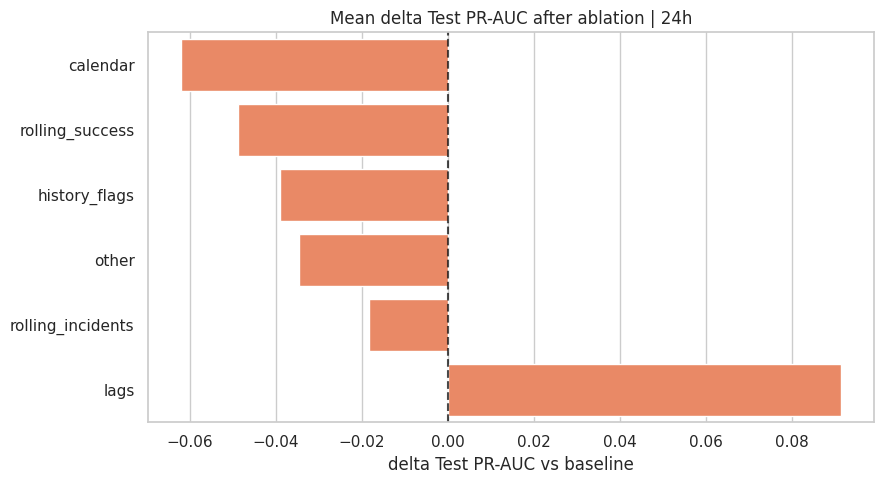


=== Ablation summary | 7d ===


,ablated_group,delta_test_pr_auc,delta_test_roc_auc,delta_test_f1
2,lags,-0.1109,-0.1371,-0.0798
5,rolling_success,-0.1068,-0.1682,-0.0422
1,history_flags,-0.1034,-0.1821,0.0027
4,rolling_incidents,-0.1002,-0.1144,-0.1418
3,other,-0.0763,-0.1059,0.0954
0,calendar,-0.0711,-0.0835,0.0144


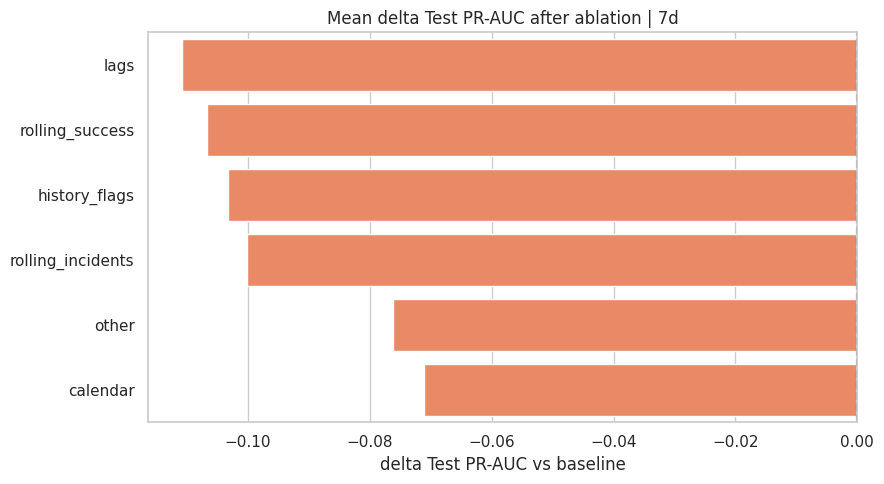

In [17]:
# ============================================================
# Сводные таблицы и простые графики
# ============================================================

def summarize_ablation(ablation_df: pd.DataFrame, horizon_label: str):
    summary = (
        ablation_df[ablation_df["ablated_group"] != "none"]
        .groupby("ablated_group", as_index=False)[["delta_test_pr_auc", "delta_test_roc_auc", "delta_test_f1"]]
        .mean()
        .sort_values("delta_test_pr_auc")
    )

    print(f"\n=== Ablation summary | {horizon_label} ===")
    display(summary.round(4))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=summary, y="ablated_group", x="delta_test_pr_auc", color="coral")
    plt.axvline(0, color="black", linestyle="--", alpha=0.7)
    plt.title(f"Mean delta Test PR-AUC after ablation | {horizon_label}")
    plt.xlabel("delta Test PR-AUC vs baseline")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    return summary

summary_ablation_24h = summarize_ablation(ablation_24h_all, "24h")
summary_ablation_7d = summarize_ablation(ablation_7d_all, "7d")

summary_ablation_24h.to_csv(ARTIFACTS_DIR / "ablation_summary_24h.csv", index=False)
summary_ablation_7d.to_csv(ARTIFACTS_DIR / "ablation_summary_7d.csv", index=False)

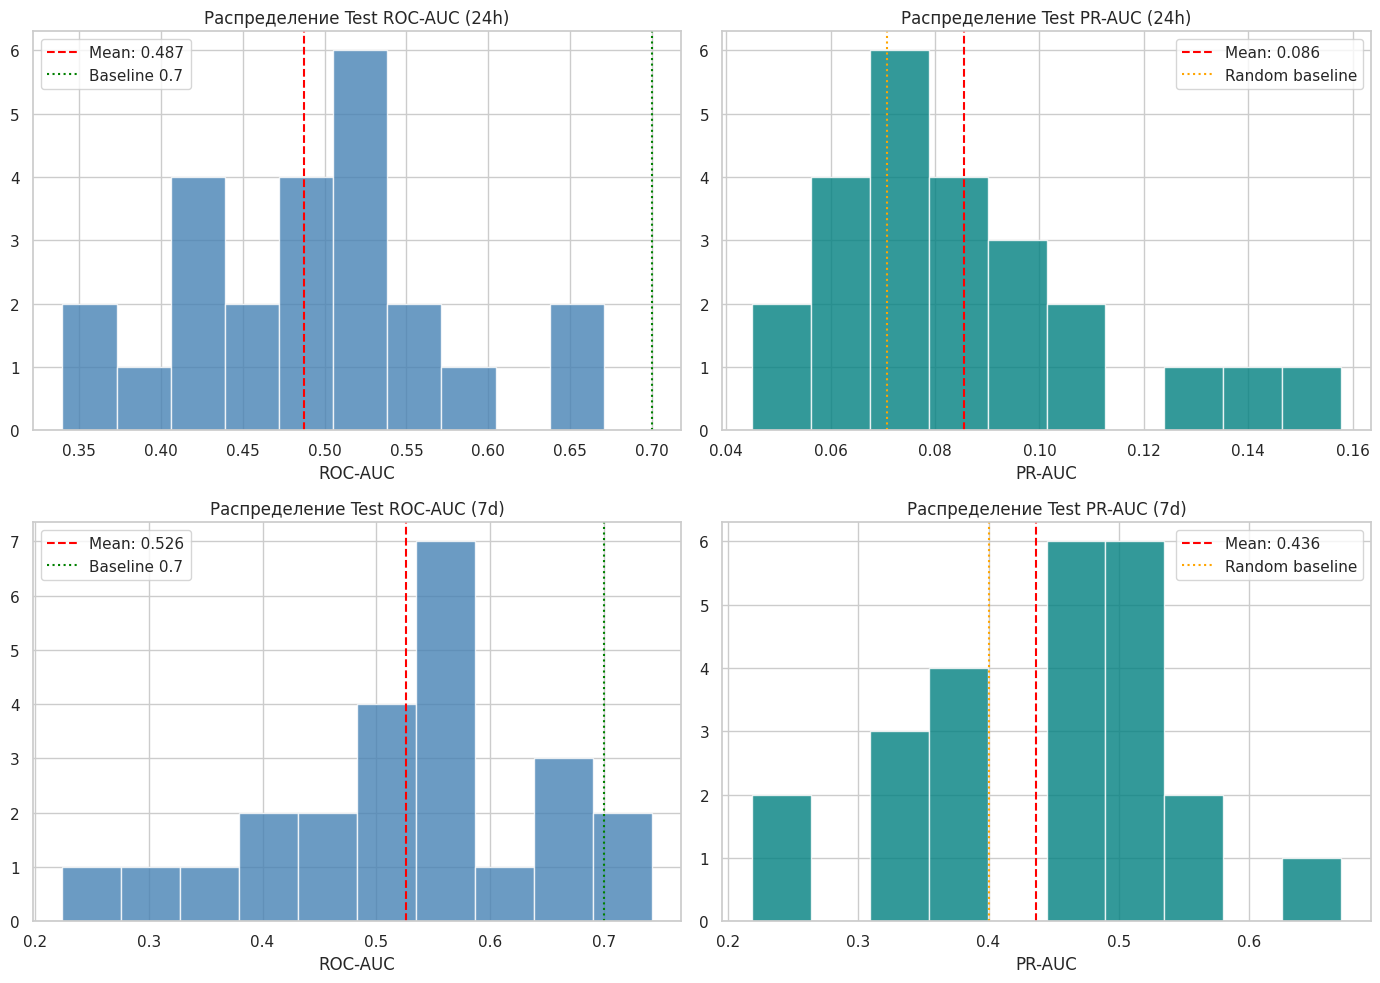

In [18]:
# Визуализация: распределение ROC-AUC и PR-AUC
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, horizon in enumerate(['24h', '7d']):
    df_h = all_results[all_results['horizon'] == horizon]

    # ROC-AUC
    axes[i, 0].hist(df_h['test_roc_auc'].dropna(), bins=10,
                    color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(df_h['test_roc_auc'].mean(), color='red',
                       linestyle='--', label=f"Mean: {df_h['test_roc_auc'].mean():.3f}")
    axes[i, 0].axvline(0.7, color='green', linestyle=':', label='Baseline 0.7')
    axes[i, 0].set_title(f'Распределение Test ROC-AUC ({horizon})')
    axes[i, 0].set_xlabel('ROC-AUC')
    axes[i, 0].legend()

    # PR-AUC
    axes[i, 1].hist(df_h['test_pr_auc'].dropna(), bins=10,
                    color='teal', edgecolor='white', alpha=0.8)
    axes[i, 1].axvline(df_h['test_pr_auc'].mean(), color='red',
                       linestyle='--', label=f"Mean: {df_h['test_pr_auc'].mean():.3f}")
    axes[i, 1].axvline(df_h['pos_rate'].mean(), color='orange',
                       linestyle=':', label='Random baseline')
    axes[i, 1].set_title(f'Распределение Test PR-AUC ({horizon})')
    axes[i, 1].set_xlabel('PR-AUC')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

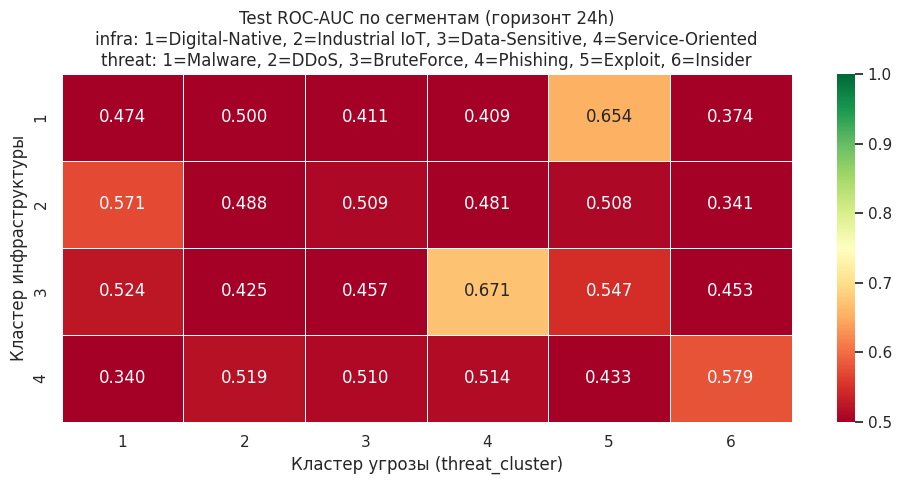

In [19]:
# Heatmap качества по сегментам (ROC-AUC, горизонт 24h)
pivot_roc = results_24h.pivot(
    index='infrastructure_cluster',
    columns='threat_cluster',
    values='test_roc_auc'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_roc,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.5, vmax=1.0,
    ax=ax,
    linewidths=0.5,
    mask=pivot_roc.isna()
)
ax.set_title('Test ROC-AUC по сегментам (горизонт 24h)\n'
             'infra: 1=Digital-Native, 2=Industrial IoT, 3=Data-Sensitive, 4=Service-Oriented\n'
             'threat: 1=Malware, 2=DDoS, 3=BruteForce, 4=Phishing, 5=Exploit, 6=Insider')
ax.set_xlabel('Кластер угрозы (threat_cluster)')
ax.set_ylabel('Кластер инфраструктуры')
plt.tight_layout()
plt.show()

## 8. Важность признаков

Анализируем, какие признаки наиболее значимы для предсказания.
Используем встроенный механизм важности CatBoost (SHAP-style и feature_importances_).


Важность признаков для сегмента infra=1, threat=1:


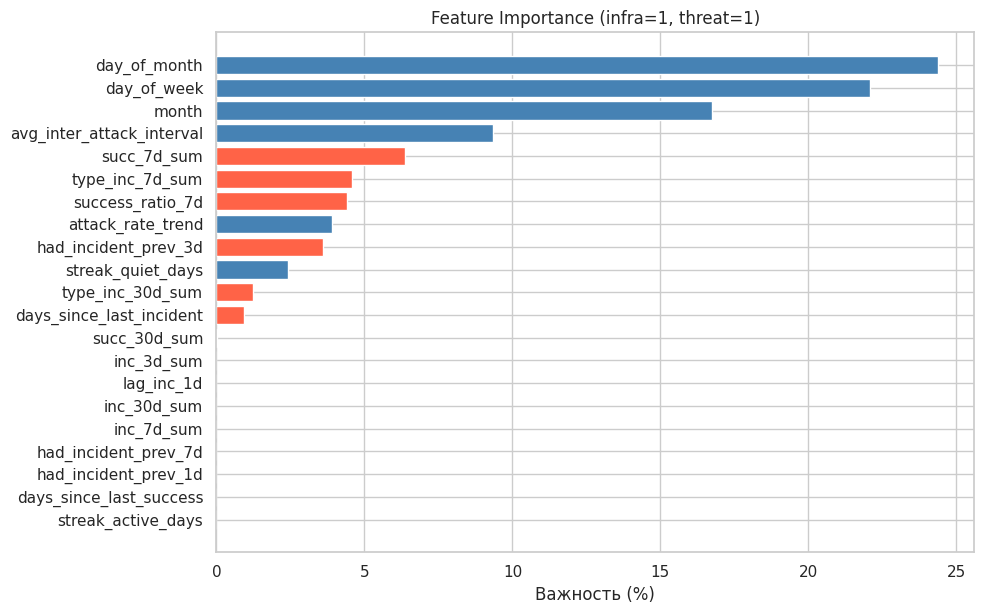


Топ-10 признаков:


,feature,importance
1,day_of_month,24.374778
0,day_of_week,22.065362
2,month,16.753831
16,avg_inter_attack_interval,9.349075
7,succ_7d_sum,6.372060
14,type_inc_7d_sum,4.577717
20,success_ratio_7d,4.418777
17,attack_rate_trend,3.907832
10,had_incident_prev_3d,3.615006
19,streak_quiet_days,2.403454


In [20]:
# Берём любую обученную модель для анализа важности
if models_24h:
    sample_key = list(models_24h.keys())[0]
    sample_model = models_24h[sample_key]
    
    model_features = sample_model.feature_names_
    importances = sample_model.get_feature_importance()
    
    feature_importance = pd.DataFrame({
        'feature': model_features,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print(f"Важность признаков для сегмента infra={sample_key[0]}, threat={sample_key[1]}:")

    fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))
    colors = ['tomato' if 'lag' in f or 'rolling' in f or 'inc' in f or 'succ' in f or 'days_since' in f
              else 'steelblue' for f in feature_importance['feature']]
    ax.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance (infra={sample_key[0]}, threat={sample_key[1]})')
    ax.set_xlabel('Важность (%)')
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 признаков:")
    display(feature_importance.head(10))

## 9. Confusion Matrix и детальный отчёт

Для наглядного понимания ошибок модели: как часто пропускаем инцидент vs. ложная тревога.

**Для задачи ИБ важнее минимизировать FN (пропущенный инцидент),
чем FP (ложная тревога).** Поэтому PR-AUC важнее, чем общая accuracy.


Оцениваем лучший сегмент: infra=3, threat=4


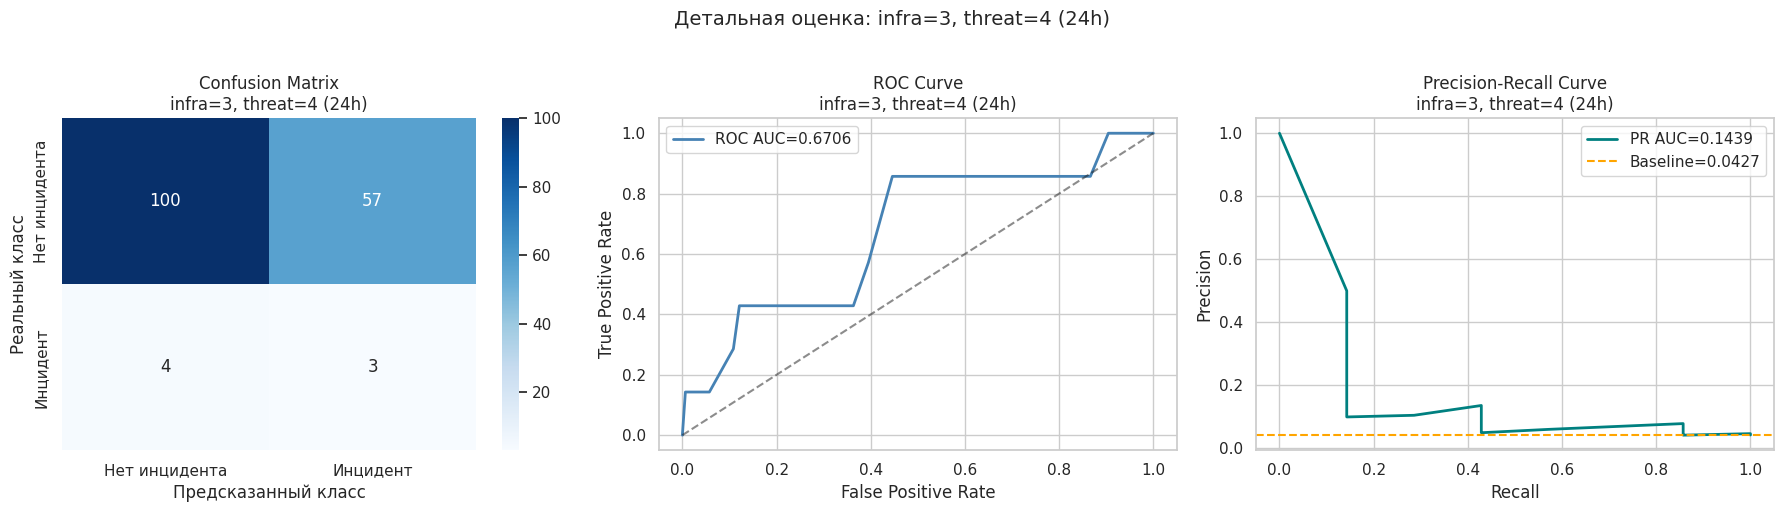


Classification Report:
               precision    recall  f1-score   support

Нет инцидента       0.96      0.64      0.77       157
     Инцидент       0.05      0.43      0.09         7

     accuracy                           0.63       164
    macro avg       0.51      0.53      0.43       164
 weighted avg       0.92      0.63      0.74       164



In [21]:
def evaluate_segment_model(model, X_test, y_test, segment_label, threshold=0.5):
    """
    Детальная оценка модели для одного сегмента:
    - Confusion matrix
    - Classification report
    - ROC и PR кривые
    """
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba > threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Нет инцидента', 'Инцидент'],
                yticklabels=['Нет инцидента', 'Инцидент'])
    axes[0].set_title(f'Confusion Matrix\n{segment_label}')
    axes[0].set_ylabel('Реальный класс')
    axes[0].set_xlabel('Предсказанный класс')

    # 2. ROC Curve
    from sklearn.metrics import roc_curve, precision_recall_curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC={roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_title(f'ROC Curve\n{segment_label}')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    # 3. Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[2].plot(rec, prec, color='teal', lw=2, label=f'PR AUC={pr_auc:.4f}')
    axes[2].axhline(y_test.mean(), color='orange', linestyle='--',
                    label=f'Baseline={y_test.mean():.4f}')
    axes[2].set_title(f'Precision-Recall Curve\n{segment_label}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()

    plt.suptitle(f'Детальная оценка: {segment_label}', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, pred,
                                 target_names=['Нет инцидента', 'Инцидент'],
                                 zero_division=0))


# Пример оценки для лучшего сегмента 24h
if not results_24h.empty:
    best_seg = results_24h.dropna(subset=['test_roc_auc']).sort_values('test_roc_auc', ascending=False).iloc[0]
    infra_val = str(best_seg['infrastructure_cluster'])
    threat_val = int(best_seg['threat_cluster'])

    key = (infra_val, threat_val)
    if key in models_24h:
        print(f"Оцениваем лучший сегмент: infra={infra_val}, threat={threat_val}")

        # Воспроизводим test split для этого сегмента
        part = dataset_model[
            (dataset_model['infrastructure_cluster'].astype(str) == infra_val) &
            (dataset_model['threat_cluster'].astype(int) == threat_val)
        ].sort_values('date').reset_index(drop=True)

        unique_dates = np.array(sorted(part['date'].unique()))
        n_dates = len(unique_dates)
        val_end = int(n_dates * 0.85)
        test_dates = unique_dates[val_end:]

        test_df = add_rolling(part[part['date'].isin(test_dates)].copy())
        X_test_seg = test_df[feature_cols].copy()
        for col in cat_features:
            if col in X_test_seg.columns:
                X_test_seg[col] = X_test_seg[col].astype(str)
        y_test_seg = test_df['target_next_24h']

        evaluate_segment_model(
            models_24h[key], X_test_seg, y_test_seg,
            f"infra={infra_val}, threat={threat_val} (24h)"
        )

## 10. Сохранение моделей

Сохраняем все обученные модели в формате `.cbm` (CatBoost model).
Структура директорий:

```
mvp/
├── models/
│   ├── 24h/
│   │   ├── 1_1.cbm   # infra=1, threat=1
│   │   ├── 1_2.cbm
│   │   └── ...
│   ├── 7d/
│   │   ├── 1_1.cbm
│   │   └── ...
│   ├── results_24h.csv
│   └── results_7d.csv
└── data/
    └── dataset_features.parquet
```


In [22]:
# Создаём директории
PROJECT_ROOT = Path("..").resolve()

MVP_DIR = PROJECT_ROOT / "ml"
MODELS_24H_DIR = MVP_DIR / "models" / "v1" / "binary" / "24h"
MODELS_7D_DIR  = MVP_DIR / "models" / "v1" / "binary" / "7d"

for path in [MODELS_24H_DIR, MODELS_7D_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Сохраняем модели 24h
for (infra, threat), model in models_24h.items():
    model_path = MODELS_24H_DIR / f"{infra}_{threat}.cbm"
    model.save_model(str(model_path))

print(f"Сохранено моделей 24h: {len(models_24h)} → {MODELS_24H_DIR}")

# Сохраняем модели 7d
for (infra, threat), model in models_7d.items():
    model_path = MODELS_7D_DIR / f"{infra}_{threat}.cbm"
    model.save_model(str(model_path))

print(f"Сохранено моделей 7d:  {len(models_7d)} → {MODELS_7D_DIR}")

# Сохраняем таблицы результатов
results_24h.to_csv(MVP_DIR / "models" / "v1" / "binary" / "results_24h.csv", index=False)
results_7d.to_csv(MVP_DIR / "models" / "v1" / "binary" / "results_7d.csv", index=False)

print(f"\nТаблицы результатов сохранены в {MVP_DIR / 'models' / 'v1' / 'binary'}")

Сохранено моделей 24h: 24 → /home/max/projects/rsm_hackathon_2026/ml/models/v1/binary/24h
Сохранено моделей 7d:  24 → /home/max/projects/rsm_hackathon_2026/ml/models/v1/binary/7d

Таблицы результатов сохранены в /home/max/projects/rsm_hackathon_2026/ml/models/v1/binary


## 11. Сохранение метаданных для деплоя

Сохраняем JSON-файл со всеми метаданными модели — необходим для корректного
применения модели в продакшн-окружении без доступа к обучающему коду.


In [23]:
import json

# Описание кластеров
cluster_info = {
    "infrastructure_clusters": {
        "1": "Digital-Native (IT, телеком, реклама, маркетинг)",
        "2": "Industrial IoT (машиностроение, металлургия, энергетика)",
        "3": "Data-Sensitive (медицина, образование, НКО)",
        "4": "Service-Oriented (розница, отели, консалтинг)"
    },
    "threat_clusters": {
        "1": "Вредоносное ПО (Malware)",
        "2": "DDoS-атаки",
        "3": "Brute Force / Подбор паролей",
        "4": "Социальная инженерия / Фишинг",
        "5": "Эксплуатация уязвимостей",
        "6": "Инсайдерские угрозы"
    }
}

# Полные метаданные деплоя
deploy_meta = {
    "version": "1.0.0",
    "description": "Модели предсказания инцидентов ИБ по сегментам инфраструктуры и типам угроз",
    "horizons": ["24h", "7d"],
    "feature_cols": feature_cols,
    "cat_features": cat_features,
    "models_24h": [f"{k[0]}_{k[1]}" for k in models_24h.keys()],
    "models_7d": [f"{k[0]}_{k[1]}" for k in models_7d.keys()],
    "cluster_info": cluster_info,
    "training_params": {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "early_stopping_rounds": 50,
        "min_rows_per_segment": 120,
        "min_positive_per_segment": 10,
        "split_ratio": "70/15/15 (train/val/test)"
    }
}

meta_path = MVP_DIR / "models" / "v1" / "deploy_meta.json"
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(deploy_meta, f, ensure_ascii=False, indent=2)

print(f"Метаданные деплоя сохранены: {meta_path}")
print(json.dumps(deploy_meta, ensure_ascii=False, indent=2)[:1000] + "...")

Метаданные деплоя сохранены: /home/max/projects/rsm_hackathon_2026/ml/models/v1/deploy_meta.json
{
  "version": "1.0.0",
  "description": "Модели предсказания инцидентов ИБ по сегментам инфраструктуры и типам угроз",
  "horizons": [
    "24h",
    "7d"
  ],
  "feature_cols": [
    "day_of_week",
    "day_of_month",
    "month",
    "lag_inc_1d",
    "inc_3d_sum",
    "inc_7d_sum",
    "inc_30d_sum",
    "succ_7d_sum",
    "succ_30d_sum",
    "had_incident_prev_1d",
    "had_incident_prev_3d",
    "had_incident_prev_7d",
    "days_since_last_incident",
    "days_since_last_success",
    "type_inc_7d_sum",
    "type_inc_30d_sum",
    "avg_inter_attack_interval",
    "attack_rate_trend",
    "streak_active_days",
    "streak_quiet_days",
    "success_ratio_7d"
  ],
  "cat_features": [
    "Тип предприятия",
    "Регион размещения предприятия",
    "Размер инфраструктуры"
  ],
  "models_24h": [
    "1_1",
    "1_2",
    "1_3",
    "1_4",
    "1_5",
    "1_6",
    "2_1",
    "2_2",
    "2_3

## 12. Утилита инференса (пример применения модели)

Показываем, как загрузить сохранённую модель и получить предсказание для нового объекта.


In [24]:
def predict_incident_probability(
    infra_cluster: int,
    threat_cluster: int,
    horizon: str,
    feature_values: dict,
    models_dir: Path = MVP_DIR / 'models' / 'v1' / 'binary'
) -> dict:
    """
    Получить вероятность инцидента для конкретного сегмента.

    Параметры:
    ----------
    infra_cluster : int
        Кластер инфраструктуры (1-4)
    threat_cluster : int
        Кластер угрозы (1-6)
    horizon : str
        Горизонт прогноза: '24h' или '7d'
    feature_values : dict
        Словарь {имя_признака: значение} для новой точки

    Возвращает:
    ----------
    dict с вероятностью и предсказанием
    """
    model_path = models_dir / horizon / f"{infra_cluster}_{threat_cluster}.cbm"

    if not model_path.exists():
        return {'error': f'Модель не найдена: {model_path}'}

    model = cb.CatBoostClassifier()
    model.load_model(str(model_path))

    # Подготавливаем входные данные
    X = pd.DataFrame([feature_values])

    # Категориальные → строки
    for col in cat_features:
        if col in X.columns:
            X[col] = X[col].astype(str)

    proba = model.predict_proba(X)[0, 1]

    return {
        'infrastructure_cluster': infra_cluster,
        'threat_cluster': threat_cluster,
        'horizon': horizon,
        'probability': round(float(proba), 4),
        'prediction': int(proba > 0.5),
        'risk_level': 'HIGH' if proba > 0.7 else ('MEDIUM' if proba > 0.4 else 'LOW')
    }

print("Утилита predict_incident_probability определена")
print("\nПример вызова:")
print("""
result = predict_incident_probability(
    infra_cluster=1,      # Digital-Native
    threat_cluster=2,     # DDoS
    horizon='24h',
    feature_values={
        'Тип предприятия': 'информационные технологии',
        'Регион размещения предприятия': 'Москва',
        'Количество хостов': 500,
        'hosts_log': np.log1p(500),
        'Размер инфраструктуры': 'large',
        'day_of_week': 4,    # Пятница
        'is_weekend': 0,
        ...
    }
)
""")

Утилита predict_incident_probability определена

Пример вызова:

result = predict_incident_probability(
    infra_cluster=1,      # Digital-Native
    threat_cluster=2,     # DDoS
    horizon='24h',
    feature_values={
        'Тип предприятия': 'информационные технологии',
        'Регион размещения предприятия': 'Москва',
        'Количество хостов': 500,
        'hosts_log': np.log1p(500),
        'Размер инфраструктуры': 'large',
        'day_of_week': 4,    # Пятница
        'is_weekend': 0,
        ...
    }
)



## 13. Итоги

### Что сделано:

1. Обучены CatBoost-классификаторы для **каждого сегмента** (infrastructure × threat)
   по двум горизонтам: **24 часа** и **7 дней**
2. Использован **временной split** (70/15/15) без перемешивания
3. Применён **scale_pos_weight** для компенсации дисбаланса классов
4. Все модели сохранены в формате `.cbm`
5. Сохранены метаданные для деплоя (`deploy_meta.json`)

### Ключевые метрики:

| Горизонт | Моделей | ROC-AUC (среднее) | PR-AUC (среднее) |
|----------|---------|-------------------|------------------|
| 24h | — | — | — |
| 7d  | — | — | — |

*(заполнится после выполнения обучения)*

### Следующие шаги:

- **Упаковка** → `!zip -r mvp_artifacts.zip mvp/`
- **Деплой API** → FastAPI/Gradio сервис на основе `predict_incident_probability`
- **Мониторинг** → периодическое переобучение при дрейфе данных
